In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
/kaggle/input/datasets/kanchandalal123/mcq-ranking-train-dataset-2/ranking_train (1).csv


# Scratch NLP Model for Smart MCQ Solver

## Objective

This notebook implements a traditional NLP pipeline from scratch for the Smart MCQ Solver Challenge.

Unlike transformer-based models, this approach relies on TF-IDF feature extraction followed by classical machine learning classifiers.

Models implemented:

- Logistic Regression
- XGBoost
- Ensemble (Average Probabilities)

This notebook also compares the performance of all three approaches using Accuracy, F1 Score and MAP@3.

The best traditional model will later be compared with DeBERTa and the Retrieval-Augmented (RAG) model.

In [2]:

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import joblib
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import wandb

In [3]:

wandb.login()

wandb.init(
    project="24f1002360-t22026",
    name="TFIDF_LR_XGBoost",
    tags=["Scratch Model", "TF-IDF", "Logistic Regression", "XGBoost"],
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f1002360 (24f1002360-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
ranking_df = pd.read_csv("/kaggle/input/datasets/kanchandalal123/mcq-ranking-train-dataset-2/ranking_train (1).csv")

print("Shape :", ranking_df.shape)

ranking_df.head()

Shape : (10000, 8)


,id,question,option_label,option_text,label,text,text_length,fold
0,1,Pick the best possible answer: What is Martin ...,A,Martin Heidegger believes that humans exist wi...,0,Question: Pick the best possible answer: What ...,474,3
1,1,Pick the best possible answer: What is Martin ...,B,Martin Heidegger believes that humans do not e...,1,Question: Pick the best possible answer: What ...,425,3
2,1,Pick the best possible answer: What is Martin ...,C,Martin Heidegger does not believe in the exist...,0,Question: Pick the best possible answer: What ...,389,3
3,1,Pick the best possible answer: What is Martin ...,D,Martin Heidegger believes that the relationshi...,0,Question: Pick the best possible answer: What ...,369,3
4,1,Pick the best possible answer: What is Martin ...,E,Martin Heidegger believes that time is an illu...,0,Question: Pick the best possible answer: What ...,358,3


In [5]:
print(ranking_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10000 non-null  int64 
 1   question      10000 non-null  object
 2   option_label  10000 non-null  object
 3   option_text   10000 non-null  object
 4   label         10000 non-null  int64 
 5   text          10000 non-null  object
 6   text_length   10000 non-null  int64 
 7   fold          10000 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 625.1+ KB
None


In [6]:
ranking_df.isnull().sum()

id              0
question        0
option_label    0
option_text     0
label           0
text            0
text_length     0
fold            0
dtype: int64

In [7]:
ranking_df["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

In [8]:

train_df = ranking_df[ranking_df.fold != 0].reset_index(drop=True)

valid_df = ranking_df[ranking_df.fold == 0].reset_index(drop=True)

print(train_df.shape)
print(valid_df.shape)

(8000, 8)
(2000, 8)


In [9]:
X_train_text = train_df["text"]

X_valid_text = valid_df["text"]

y_train = train_df["label"]

y_valid = valid_df["label"]

In [10]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=30000,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_train = tfidf.fit_transform(X_train_text)

X_valid = tfidf.transform(X_valid_text)

print(X_train.shape)
print(X_valid.shape)

(8000, 11154)
(2000, 11154)


In [11]:
print("Original text")

print(train_df.text.iloc[0])

Original text
Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. [SEP] Option: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.


### Logistic Regression

In [12]:
import time

start_time = time.time()

lr = LogisticRegression(
    max_iter=1000,
    C=2,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)

end_time = time.time()

lr_training_time = end_time - start_time

print(f"Training Time : {lr_training_time:.2f} sec")

Training Time : 2.11 sec


In [13]:
valid_pred = lr.predict(X_valid)

valid_prob = lr.predict_proba(X_valid)[:, 1]

In [14]:
accuracy = accuracy_score(y_valid, valid_pred)

f1 = f1_score(
    y_valid,
    valid_pred,
    average="binary"
)

print(f"Validation Accuracy : {accuracy:.4f}")

print(f"Validation F1 Score : {f1:.4f}")

Validation Accuracy : 0.9045
Validation F1 Score : 0.6864


In [15]:
print(classification_report(
    y_valid,
    valid_pred
))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1600
           1       1.00      0.52      0.69       400

    accuracy                           0.90      2000
   macro avg       0.95      0.76      0.82      2000
weighted avg       0.91      0.90      0.89      2000



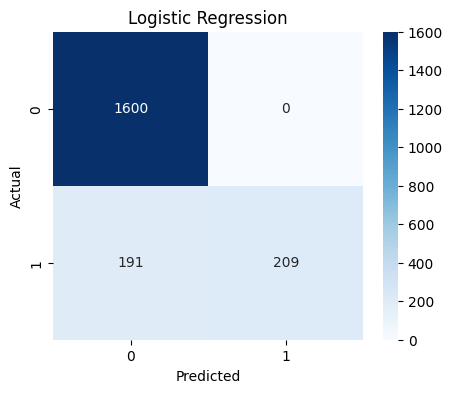

In [16]:
cm = confusion_matrix(y_valid, valid_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [17]:
def apk(actual, predicted, k=3):

    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i, p in enumerate(predicted):

        if p == actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1)

    return score


def mapk(actuals, predictions, k=3):

    return np.mean([
        apk(a, p, k)
        for a, p in zip(actuals, predictions)
    ])

In [18]:

valid_results = valid_df.copy()

valid_results["score"] = valid_prob

valid_results.head()

predictions = []

ground_truth = []

for qid, group in valid_results.groupby("id"):

    group = group.sort_values(
        "score",
        ascending=False
    )

    predicted = group["option_label"].tolist()

    actual = group.loc[
        group["label"] == 1,
        "option_label"
    ].values[0]

    predictions.append(predicted)

    ground_truth.append(actual)

map3 = mapk(
    ground_truth,
    predictions,
    k=3
)

print(f"Validation MAP@3 : {map3:.5f}")

Validation MAP@3 : 0.97500


In [19]:
wandb.log({

    "LR/Accuracy": accuracy,

    "LR/F1": f1,

    "LR/MAP@3": map3,

    "LR Training Time (sec)": lr_training_time,

    "Vocabulary Size": len(tfidf.vocabulary_),

    "TF-IDF Features": X_train.shape[1],

    "Training Samples": len(train_df),

    "Validation Samples": len(valid_df),

    "Positive Samples": int(y_train.sum()),

    "Negative Samples": int(len(y_train)-y_train.sum()),

    "Classifier":"Logistic Regression"

})

### XGBoost

In [20]:
import time

start_time = time.time()

xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1

)

xgb.fit(X_train, y_train)

end_time = time.time()

xgb_training_time = end_time-start_time

print(f"Training Time : {xgb_training_time:.2f} sec")

Training Time : 23.28 sec


In [21]:
xgb_pred = xgb.predict(X_valid)

xgb_prob = xgb.predict_proba(X_valid)[:,1]

In [22]:
xgb_accuracy = accuracy_score(

    y_valid,

    xgb_pred

)

xgb_f1 = f1_score(

    y_valid,

    xgb_pred

)

print(f"Validation Accuracy : {xgb_accuracy:.4f}")

print(f"Validation F1 Score : {xgb_f1:.4f}")

Validation Accuracy : 0.8820
Validation F1 Score : 0.5860


In [23]:
print(classification_report(

    y_valid,

    xgb_pred

))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1600
           1       0.98      0.42      0.59       400

    accuracy                           0.88      2000
   macro avg       0.93      0.71      0.76      2000
weighted avg       0.89      0.88      0.86      2000



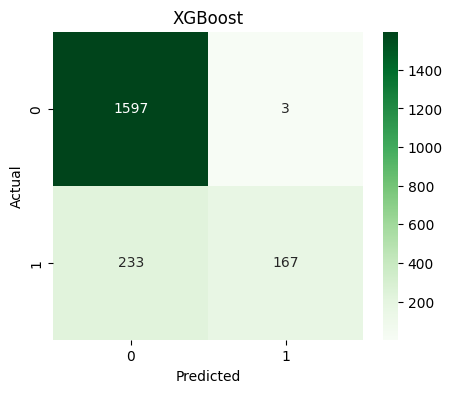

In [24]:
cm = confusion_matrix(

    y_valid,

    xgb_pred

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost")

plt.show()

In [25]:
xgb_results = valid_df.copy()

xgb_results["score"] = xgb_prob

predictions=[]

ground_truth=[]

for qid,group in xgb_results.groupby("id"):

    group=group.sort_values(

        "score",

        ascending=False

    )

    predictions.append(

        group["option_label"].tolist()

    )

    ground_truth.append(

        group.loc[

            group.label==1,

            "option_label"

        ].values[0]

    )

xgb_map3=mapk(

    ground_truth,

    predictions,

    k=3

)

print(f"Validation MAP@3 : {xgb_map3:.5f}")

Validation MAP@3 : 0.93292


In [26]:
wandb.log({

    "XGB/Accuracy":xgb_accuracy,

    "XGB/F1":xgb_f1,

    "XGB/MAP@3":xgb_map3,

    "XGB Training Time (sec)":xgb_training_time,

    "Trees":300,

    "Learning Rate":0.05,

    "Max Depth":6

})

### Ensemble 

In [27]:
ensemble_prob = (

    valid_prob +

    xgb_prob

) / 2

In [28]:
ensemble_results = valid_df.copy()

ensemble_results["score"] = ensemble_prob

predictions = []

ground_truth = []

for qid, group in ensemble_results.groupby("id"):

    group = group.sort_values(

        "score",

        ascending=False

    )

    predictions.append(

        group["option_label"].tolist()

    )

    ground_truth.append(

        group.loc[
            group.label == 1,
            "option_label"
        ].values[0]
    )

ensemble_map3 = mapk(

    ground_truth,

    predictions,

    k=3

)

print(f"Ensemble MAP@3 : {ensemble_map3:.5f}")

Ensemble MAP@3 : 0.97750


In [29]:
wandb.log({

    "Ensemble/MAP@3":ensemble_map3

})

### comparison 

In [30]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "XGBoost",

        "Ensemble"

    ],

    "Accuracy":[

        accuracy,

        xgb_accuracy,

        np.nan

    ],

    "F1":[

        f1,

        xgb_f1,

        np.nan

    ],

    "MAP@3":[

        map3,

        xgb_map3,

        ensemble_map3

    ]

})

comparison

,Model,Accuracy,F1,MAP@3
0,Logistic Regression,0.9045,0.686371,0.975000
1,XGBoost,0.8820,0.585965,0.932917
2,Ensemble,NaN,NaN,0.977500


### save models 

In [31]:
os.makedirs("saved_models", exist_ok=True)

joblib.dump(

    tfidf,

    "saved_models/tfidf.pkl"

)

joblib.dump(

    lr,

    "saved_models/logistic_regression.pkl"

)

joblib.dump(

    xgb,

    "saved_models/xgboost.pkl"

)

print("Models Saved Successfully")

Models Saved Successfully


### inference 

In [32]:
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(test.shape)

test.head()

(500, 7)


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [33]:
ranking_test = []

options = ["A", "B", "C", "D", "E"]

for _, row in test.iterrows():

    for option in options:

        ranking_test.append({

            "id": row["id"],

            "option_label": option,

            "text":
                f"Question: {row['prompt']} "
                f"[SEP] Option: {row[option]}"

        })

ranking_test = pd.DataFrame(ranking_test)

print(ranking_test.shape)

ranking_test.head()

(2500, 3)


,id,option_label,text
0,1,A,Question: Pick the best possible answer: What ...
1,1,B,Question: Pick the best possible answer: What ...
2,1,C,Question: Pick the best possible answer: What ...
3,1,D,Question: Pick the best possible answer: What ...
4,1,E,Question: Pick the best possible answer: What ...


In [34]:
X_test = tfidf.transform(

    ranking_test["text"]

)

print(X_test.shape)

(2500, 11154)


In [35]:

lr_test_prob = lr.predict_proba(

    X_test

)[:,1]

In [36]:

xgb_test_prob = xgb.predict_proba(

    X_test

)[:,1]

In [37]:

ranking_test["score"] = (

    lr_test_prob +

    xgb_test_prob

)/2

In [38]:

submission = []

for qid, group in ranking_test.groupby("id"):

    group = group.sort_values(

        "score",

        ascending=False

    )

    top3 = group["option_label"].tolist()[:3]

    submission.append({

        "id": qid,

        "prediction": " ".join(top3)

    })

submission = pd.DataFrame(submission)

submission.head()

,id,prediction
0,1,A E B
1,2,B E A
2,3,B E D
3,4,E C D
4,5,C A B


In [39]:

submission.to_csv(

    "submission.csv",

    index=False

)

print(submission.head())

print()

print("Submission Saved Successfully!")

   id prediction
0   1      A E B
1   2      B E A
2   3      B E D
3   4      E C D
4   5      C A B

Submission Saved Successfully!


In [42]:
os.makedirs("saved_models", exist_ok=True)

joblib.dump(
    tfidf,
    "/kaggle/working/saved_models/tfidf.pkl"
)

joblib.dump(
    lr,
    "/kaggle/working/saved_models/logistic_regression.pkl"
)

joblib.dump(
    xgb,
    "/kaggle/working/saved_models/xgboost.pkl"
)

print("All models saved successfully.")

All models saved successfully.


In [41]:
wandb.finish()

Ensemble/MAP@3,▁
LR Training Time (sec),▁
LR/Accuracy,▁
LR/F1,▁
LR/MAP@3,▁
Learning Rate,▁
Max Depth,▁
Negative Samples,▁
Positive Samples,▁
TF-IDF Features,▁
+8,...
